In [1]:
import os
import sys
import math
import itertools
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
import scipy.sparse as sp
from libpysal import weights
from libpysal.weights import util, WSP
from esda import Moran_Local
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib import font_manager, rcParams
import seaborn as sns
import re
from collections.abc import Mapping
import matplotlib.ticker as ticker
from analysis import picture_with_field

from analysis import gmm_overlap_score,bivariate_gaussian,top1_component_overlap,load_pkl_by_timestep,replace_outliers_custom,plot_range_grid

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/libpysal/weights/util.py:23: UserWarning: geopandas not available. Some functionality will be disabled.
  warn("geopandas not available. Some functionality will be disabled.")


In [2]:
# 添加 Trajectron++ 所在路径
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_gen/TJ/trajectron')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_ana')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/trajectron')
#from analysis import gaussian_parameter,bivariate_gaussian,gmm_overlap_score,load_pkl_by_timestep,replace_outliers_custom

plt.rcParams.update({ 
    'font.family' : 'Liberation Serif',
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'serif',
    # 隐藏上边框和刻度
    'axes.spines.top': True,
    # 保留其他边框和小刻度
    'axes.spines.right': True,
    'axes.spines.bottom': True,
    'axes.spines.left': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    # 刻度朝内
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    # 右侧和上侧的刻度也朝内
    'xtick.top': False,
    'ytick.right': False,
    # 关闭网格
    'axes.grid': False,
})
#TJ_tru_94_VEHICLE

In [3]:
def data_pre(predic, true, history):   
    base_dir =f"/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ"

    with open(os.path.join(base_dir, f"{predic}.pkl"), 'rb') as f:
        pre_full = pickle.load(f)

    with open(os.path.join(base_dir, f"{true}.pkl"), 'rb') as f:
        tru = pickle.load(f)

    with open(os.path.join(base_dir, f"{history}.pkl"), 'rb') as f:
        his = pickle.load(f)

    def key_to_str(k):
        # Trajectron Node: 有 type.name 和 id
        if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
            return f"{k.type.name}/{k.id}"  # id 会自动转成 str
        return str(k)
    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}
    return pre_full,tru,his

In [4]:
def print_two_level_keys(pre_full):
    for outer_k, inner_dict in pre_full.items():
        print(str(outer_k))                      # 打印第一层键
        for inner_k in inner_dict.keys():
            print("   →", str(inner_k))         # 打印第二层键，缩进
#print_two_level_keys(pre_full)

def tra_data(time_step,agent_id):
    ts = str(time_step)
    tru_traj = np.asarray(tru[ts][agent_id])
    his_traj = np.asarray(his[ts][agent_id])
    pre_traj = np.asarray(pre_full[ts][agent_id])
        # break  # 找到就退出
    return tru_traj,his_traj,pre_traj[0]

In [5]:
base_path = '/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/TJ'

pre_full,tru,his=data_pre('TJ_pre_full_65_2401','TJ_tru_65_2401','TJ_his_65_2401')

mus_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_mus_65_VEHICLE_2401.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
sigmas_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_sigmas_65_VEHICLE_2401.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
log_pis_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_log_pis_65_VEHICLE_2401.pkl')).detach().cpu().numpy()[0]  # [1717,12, 25]
corrs_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_corrs_65_VEHICLE_2401.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
id_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_id_65_VEHICLE_2401.pkl')) 
frame_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_frame_65_VEHICLE_2401.pkl'))
feature_all_car = load_pkl_by_timestep(os.path.join(base_path, 'TJ_feature_65_VEHICLE_2401.pkl'))

mus_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_mus_65_PEDESTRIAN_2401.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
sigmas_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_sigmas_65_PEDESTRIAN_2401.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
log_pis_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_log_pis_65_PEDESTRIAN_2401.pkl'))[0].detach().cpu().numpy()  # [1717,12, 25]
corrs_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_corrs_65_PEDESTRIAN_2401.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
id_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_id_65_PEDESTRIAN_2401.pkl'))
frame_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_frame_65_PEDESTRIAN_2401.pkl'))
feature_all_ped = load_pkl_by_timestep(os.path.join(base_path, 'TJ_feature_65_PEDESTRIAN_2401.pkl'))

In [6]:
def gaussian_parameter(time_step, agent_id):
    """
    输入:
        time_step : int
        agent_id  : 'PEDESTRIAN/178' 或 'VEHICLE/178'
    输出:
        mus[x], sigmas[x], log_pis[x], corrs[x]
    """
    # 取 ID 末尾数字
    target_id = agent_id.split('/')[-1]   # '178'
    # 判断行人 / 车辆
    if agent_id.startswith("PEDESTRIAN/"):
        frame_arr = frame_all_ped
        id_arr    = id_all_ped
        mus_arr   = mus_all_ped
        sig_arr   = sigmas_all_ped
        logpi_arr = log_pis_all_ped
        corr_arr  = corrs_all_ped
        feature_arr  = feature_all_ped
    elif agent_id.startswith("VEHICLE/"):
        frame_arr = frame_all_car
        id_arr    = id_all_car
        mus_arr   = mus_all_car
        sig_arr   = sigmas_all_car
        logpi_arr = log_pis_all_car
        corr_arr  = corrs_all_car
        feature_arr  = feature_all_car
    else:
        raise ValueError(f"ID 必须以 'PEDESTRIAN/' 或 'VEHICLE/' 开头: {agent_id}")
    # 转 numpy（确保可 where）
    frame_arr = np.asarray(frame_arr)
    id_arr    = np.asarray(id_arr)
    # 找到所有时间步匹配
    idx_ts = np.where(frame_arr == time_step)[0]
    # 匹配对应ID（直接比较字符串）
    matches = [i for i in idx_ts if str(id_arr[i]).split('/')[-1] == target_id]
    if len(matches) == 0:
        raise ValueError(f"time_step={time_step} 下没有找到 {agent_id}")
    if len(matches) > 1:
        raise ValueError(f"time_step={time_step} 下找到多个 {agent_id}，应唯一 → {matches}")
    x = matches[0]
    return mus_arr[x], sig_arr[x], logpi_arr[x], corr_arr[x],feature_arr[x]
    

inner_total = sum(len(v) for v in pre_full.values())
frame_list=list(pre_full.keys())
ped_name_per_timestep = []
ped_number_per_timestep = []
car_name_per_timestep = []
car_number_per_timestep = []
for T in range(len(frame_list)):
    frame_key = frame_list[T]  # 外层键，如 '1', '2', '3'
    agent_ids = list(pre_full[frame_key].keys())  # ['VEHICLE/8', 'PEDESTRIAN/12', ...]
    # 分离车辆与行人
    cars = [aid for aid in agent_ids if aid.startswith("VEHICLE/")]
    peds = [aid for aid in agent_ids if aid.startswith("PEDESTRIAN/")]
    # 记录
    car_name_per_timestep.append(cars)
    car_number_per_timestep.append(len(cars))
    ped_name_per_timestep.append(peds)
    ped_number_per_timestep.append(len(peds))

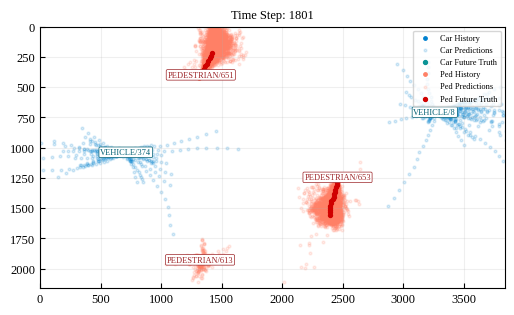

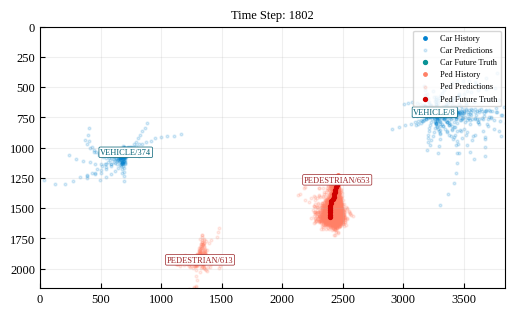

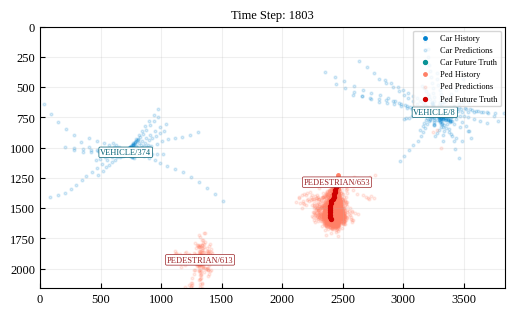

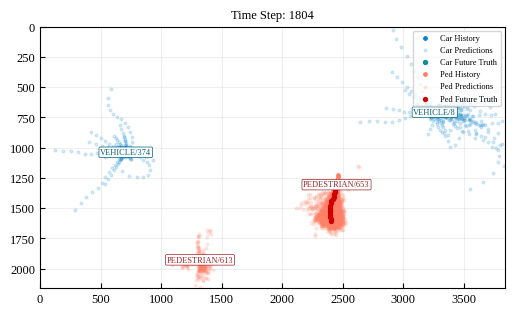

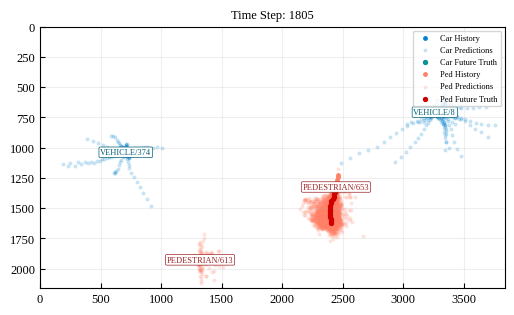

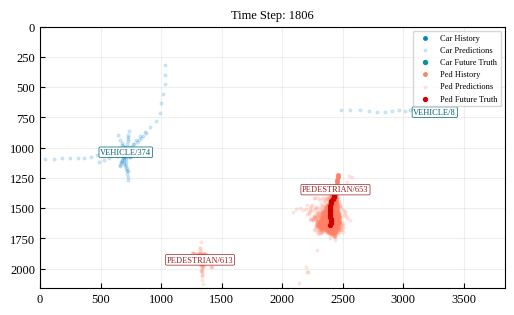

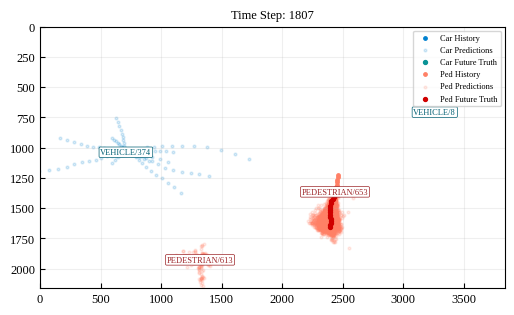

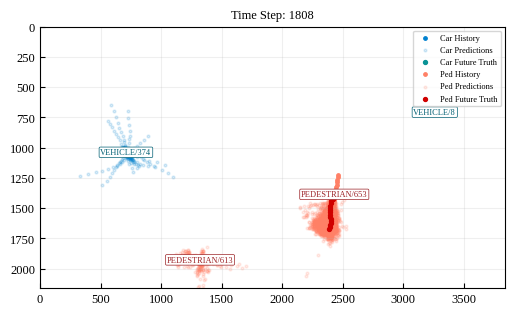

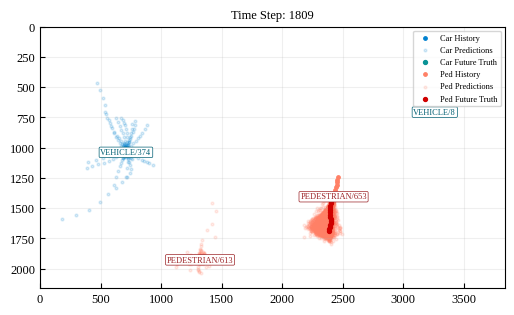

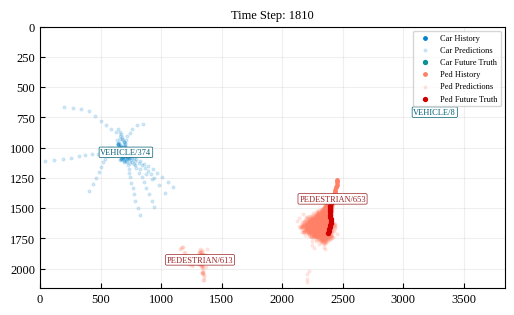

KeyboardInterrupt: 

In [7]:
for time_step in frame_list:
    fig, ax = plt.subplots(figsize=(6, 6))
    # 背景图（如不需要可注释掉）
    # img = plt.imread(r'/home/wangtao/下载/Trajectron_ped_car/SinD/Chongqing_NR/Chongqing_NR.png')
    # ax.imshow(img, extent=[0, 3840, 0,2160], zorder=0, alpha=0.85)
    # ========== ① 先画车辆 ==========
    for agent in tru[time_step].keys():
        if agent.startswith("VEHICLE/"):
            #print(agent)
            tru_car, his_car, pre_car = tra_data(time_step, agent)

            ax.scatter(his_car[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_car[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#0081cf', s=6, label='Car History', zorder=2)
            ax.scatter(pre_car[:, :, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), pre_car[:, :, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#0081cf', alpha=0.15, s=4, label='Car Predictions', zorder=1)
            ax.scatter(tru_car[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), tru_car[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#0a9396', s=8, label='Car Future Truth', zorder=3)

            if his_car.shape[0] > 0:
                ax.text(his_car[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_car[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), agent,
                        fontsize=6, color='#005f73',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#005f73', lw=0.5), zorder=4)
        else:
    # ========== ② 再画行人（颜色区分） ==========
            tru_p, his_p, pre_p = tra_data(time_step, agent)
            ax.scatter(his_p[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_p[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#ff8066', s=6, label='Ped History', zorder=2)
            ax.scatter(pre_p[:, :, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), pre_p[:, :, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#ff8066', alpha=0.15, s=4, label='Ped Predictions', zorder=1)
            ax.scatter(tru_p[:, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), tru_p[:, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), c='#d00000', s=8, label='Ped Future Truth', zorder=3)

            if his_p.shape[0] > 0:
                ax.text(his_p[-1, 0]* (3840/(23.99+55.51))+23.99*(3840/(23.99+55.51)), his_p[-1, 1]*(2160/(7.643+38.69))+7.64*(2160/(7.643+38.69)), agent,
                        fontsize=6, color='#9b2226',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#9b2226', lw=0.5), zorder=4)
    # ========== 坐标 & 样式 ==========
    ax.set_title(f'Time Step: {time_step}')
    ax.set_aspect('equal')
    ax.set_xlim(0, 3840)
    ax.set_ylim(2160, 0)   # 坐标原点在左上角
    ax.grid(alpha=0.2)
    # 去除重复图例（可选）
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=6, loc='upper right')
    plt.show()

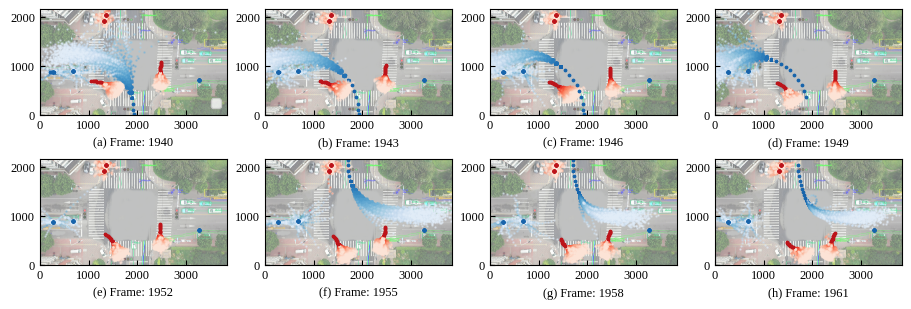

In [8]:
# 调用示例
plot_range_grid(tra_data,tru,start=1940, step=3, count=8)

In [9]:
from analysis import picture

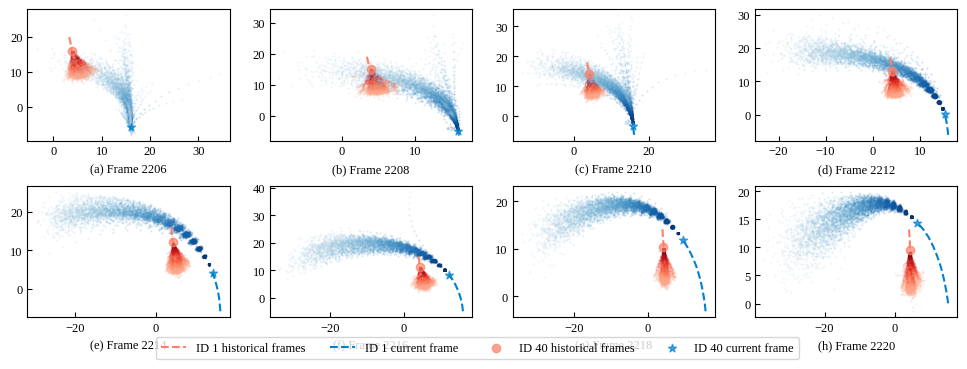

In [10]:
picture(tra_data,'PEDESTRIAN/664','VEHICLE/439',range(2206,2206+16,2),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

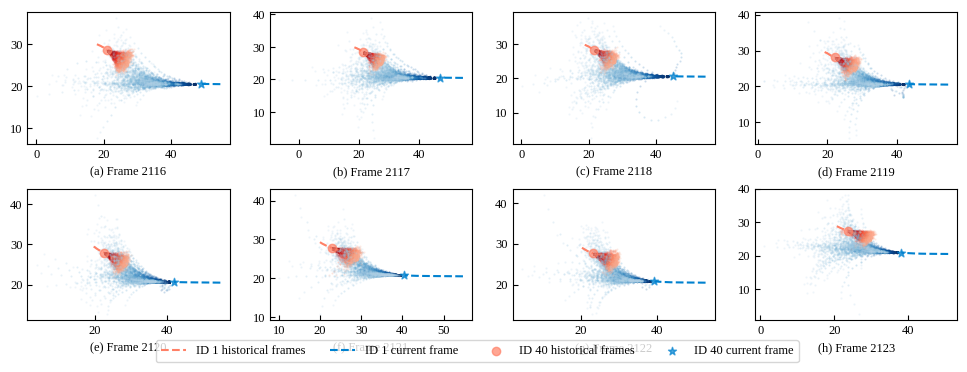

In [11]:
picture(tra_data,'PEDESTRIAN/660','VEHICLE/434',range(2116,2116+8,1),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

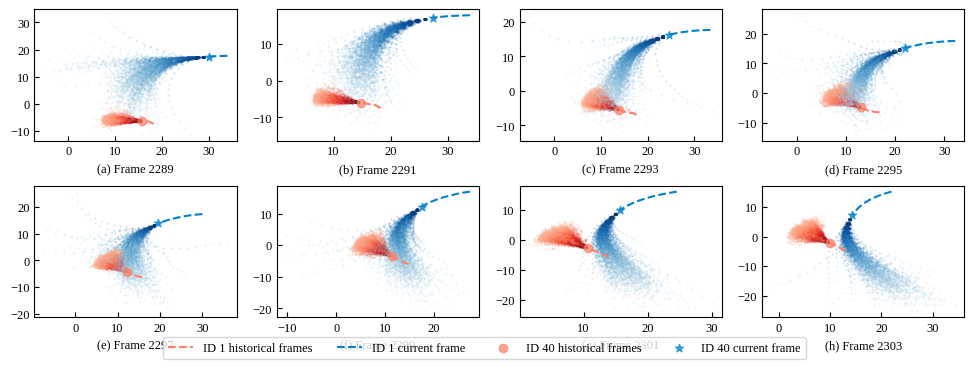

In [12]:
picture(tra_data,'PEDESTRIAN/665','VEHICLE/460',range(2289,2289+16,2),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

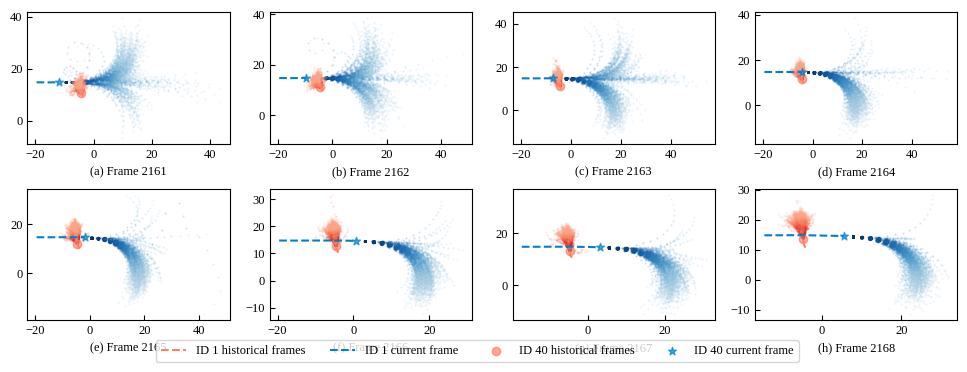

In [13]:
picture(tra_data,'PEDESTRIAN/662','VEHICLE/445',range(2161,2161+8,1),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

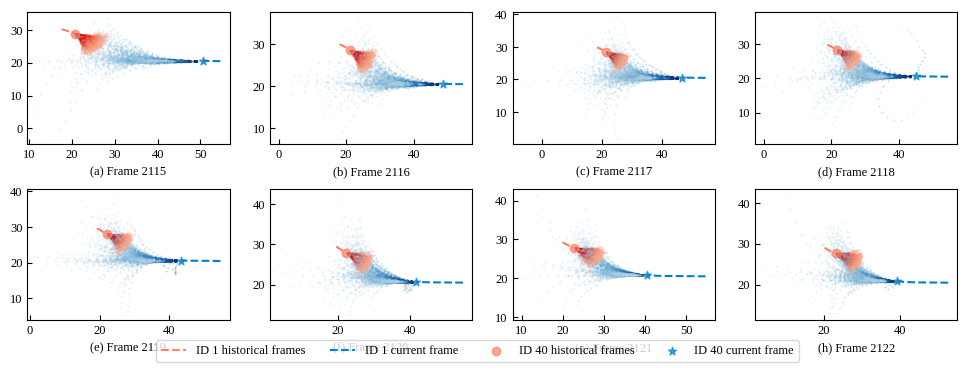

In [14]:
picture(tra_data,'PEDESTRIAN/660','VEHICLE/434',range(2115,2115+8,1),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

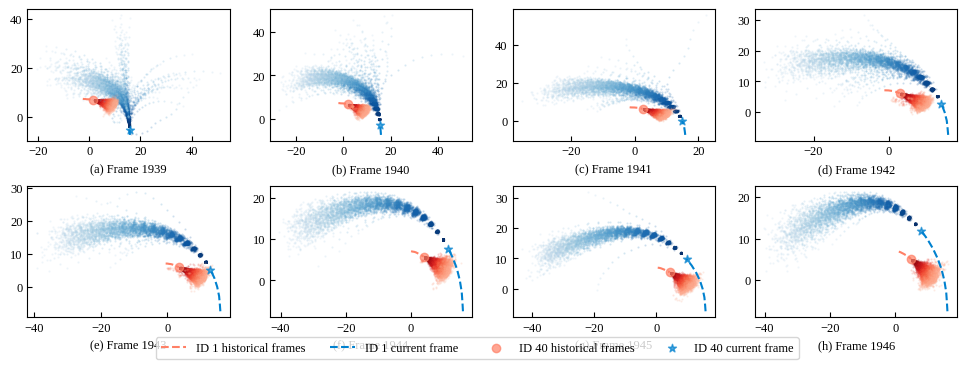

In [15]:
picture(tra_data,'PEDESTRIAN/658','VEHICLE/406',range(1939,1939+8,1),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

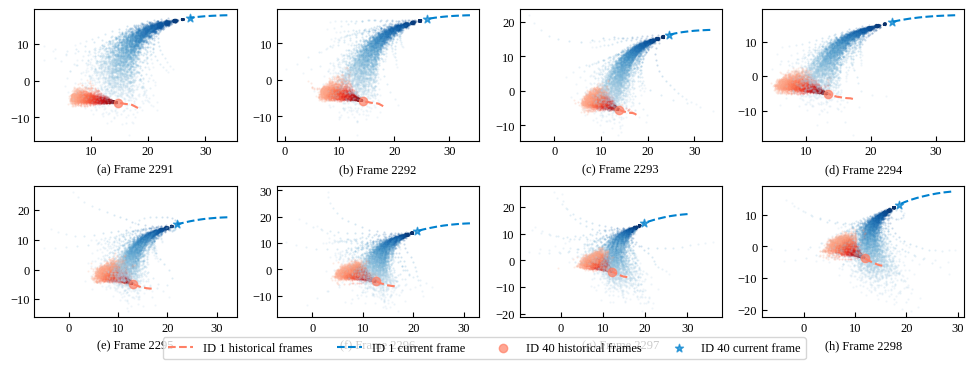

In [16]:
picture(tra_data,'PEDESTRIAN/665','VEHICLE/460',range(2291,2291+8,1),'ID 1 historical frames','ID 1 current frame','ID 40 historical frames','ID 40 current frame',"Picture/merge.png")

In [17]:
from analysis import picture_single

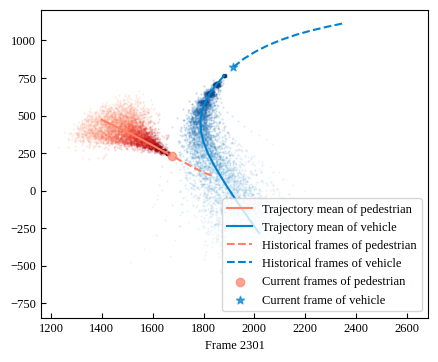

In [18]:
picture_single(tra_data,'PEDESTRIAN/665','VEHICLE/460', 2301,'Historical frames of pedestrian', 'Historical frames of vehicle','Current frames of pedestrian', 'Current frame of vehicle','/home/wangtao/下载/Trajectron-ped-veh/Data_ana/trajectory.png')

In [180]:
# def bc_normalized_field(time_step, pre_time_step, name_vid, eps=1e-12):
#     """
#     返回 q(x,y) = sqrt(p_i * p_j) / ∫∫ sqrt(p_i * p_j) dx dy
#     输出 shape 与 x,y 网格一致
#     依赖:
#       - cr(time_step, pre_time_step, name_vid) -> shape (N, 2)
#       - 全局网格 x, y 为 np.ndarray，形如 meshgrid, 同形状 (H, W)
#     """
#     f = cr(time_step, pre_time_step, name_vid)     # (N, 2)
#     p_i = np.clip(f[:, 0], 0.0, None)              # 数值安全，避免微小负数
#     p_j = np.clip(f[:, 1], 0.0, None)

#     K = np.sqrt(p_i * p_j)                         # 局部 BC 核
#     K_img = K.reshape(x.shape[0], x.shape[1])      # 还原到网格

#     # 计算网格步长（均匀网格）
#     # 若 x,y 是由 np.meshgrid 生成的规则网格，这样取 dx,dy
#     if x.shape[1] > 1:
#         dx = float(np.mean(np.diff(x[0, :])))
#     else:
#         dx = 1.0
#     if y.shape[0] > 1:
#         dy = float(np.mean(np.diff(y[:, 0])))
#     else:
#         dy = 1.0

#     # 离散积分 ≈ sum(K) * dx * dy  → 这就是 BC
#     bc = float(np.sum(K_img) * dx * dy)

#     # 归一化（若 bc≈0，用 eps 防止除零）
#     q_img = K_img / max(bc, eps)

#     return q_img

In [19]:
def final_prob_from_R(R_values, T=2.4, eps=1e-9):
    """
    R_values: 长度为 N 的数组/列表, 存储等间隔时间上的 R(t_i)
    T: 总时长 (秒)，默认 2.4
    返回:
        P: 1 - exp(-∫ lambda dt)
        lam: 各时刻的 lambda(t_i)
        integral: 近似的 ∫_0^T lambda(t) dt
    """
    R = np.asarray(R_values, dtype=float)

    # 数值安全 & 处理 NaN
    R = np.nan_to_num(R)
    R[np.isnan(R)] = 0.0
    R = np.clip(R, 0.0 + eps, 1.0 - eps)

    # λ(t) = R / (1 - R)
    lam = R / (1.0 - R)

    # 等间隔时间轴（12 点覆盖 [0, T]）
    N = len(R)
    t = np.linspace(0.0, T, N)

    # 对 λ(t) 做时间积分（梯形法）
    integral = np.trapz(lam, t)

    # 最终量：1 - exp(-∫ λ dt)
    P = 1.0 - np.exp(-integral)
    return P

def two_conflict_risk(time,veh1,veh2):
    Time_risk_6511_6528=[]
    for t in time:
        new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
        new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
        risk=[]
        for i in range(0,16):
            S = gmm_overlap_score(
                    new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                    new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
            risk.append(S)
        risk_c=[v * 0.99**t*0.4 for t, v in enumerate(risk)]
        Time_risk_6511_6528.append(final_prob_from_R(risk_c))
    return Time_risk_6511_6528

In [20]:
# picture_with_field(tra_data,gaussian_parameter,1000,2000,1160,160,
#     agent_A='PEDESTRIAN/658',
#     agent_B='VEHICLE/406',
#     time_duration=range(1939,1939+8,1),   # 8 个时间步
#     label_A='ID 1 historical frames',
#     label_B='ID 40 historical frames',
#     label_A_1='ID 1 current frame',
#     label_B_1='ID 40 current frame')

全局颜色范围(原始数据) vmin, vmax = 0.0 0.0032869105441303754


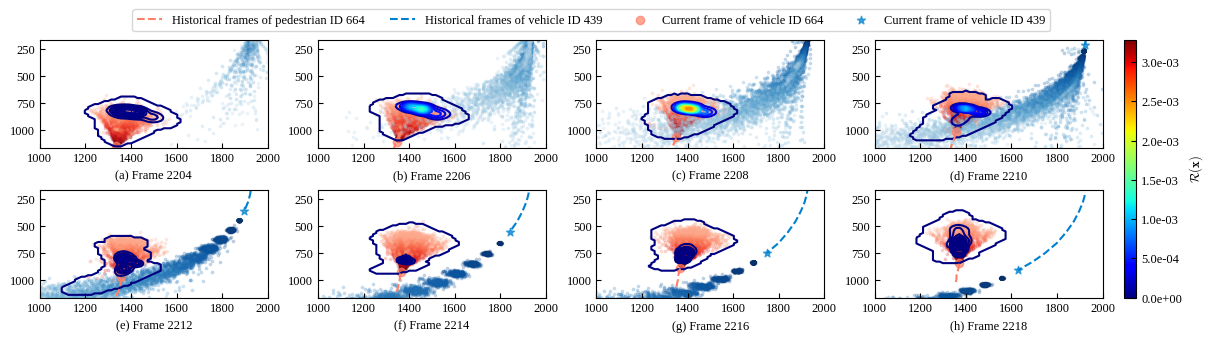

In [21]:
picture_with_field(tra_data,gaussian_parameter,1000,2000,1160,160,
    agent_A='PEDESTRIAN/664',
    agent_B='VEHICLE/439',
    time_duration=range(2204,2204+16,2),   # 8 个时间步
    label_A='Historical frames of pedestrian ID 664',
    label_B='Historical frames of vehicle ID 439',
    label_A_1='Current frame of vehicle ID 664',
    label_B_1='Current frame of vehicle ID 439',save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/sca11.png')

全局颜色范围(原始数据) vmin, vmax = 0.0 0.001869775245678175


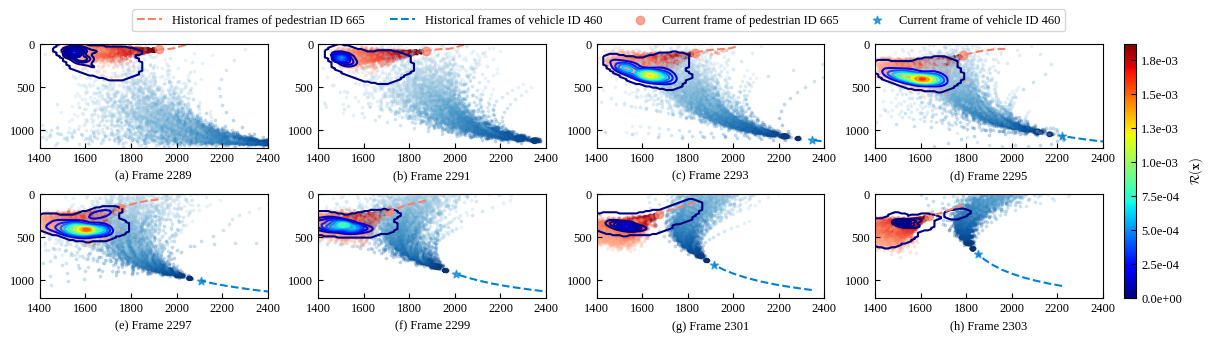

In [22]:
picture_with_field(tra_data,gaussian_parameter,1400,2400,1200,0,
    agent_A='PEDESTRIAN/665',
    agent_B='VEHICLE/460',
    time_duration=range(2289,2289+16,2),   # 8 个时间步
    label_A='Historical frames of pedestrian ID 665',
    label_B='Historical frames of vehicle ID 460',
    label_A_1='Current frame of pedestrian ID 665',
    label_B_1='Current frame of vehicle ID 460',save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/sca22.png')

In [23]:
from analysis import picture_single_with_field_one_timestep

In [24]:
#1000,3840,1700,700,

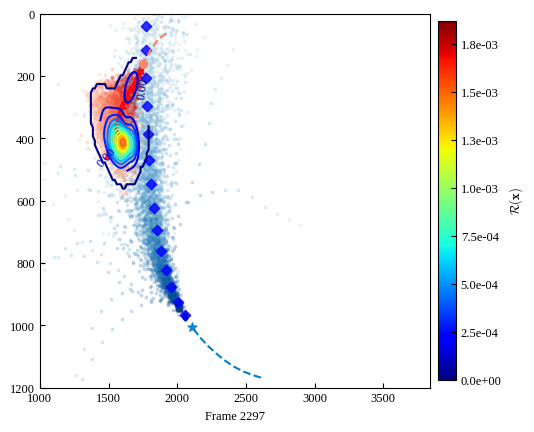

(<Figure size 520x420 with 2 Axes>, <AxesSubplot:xlabel='Frame 2297'>)

In [25]:
picture_single_with_field_one_timestep(
    tra_data, gaussian_parameter,
1000,3840,1200,0,
    agent_A='PEDESTRIAN/665',
    agent_B='VEHICLE/460', timestep=2297,
    label_A="V", label_B="P",
    label_A_1="V", label_B_1="P",save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/f2.png'
)

In [26]:
# picture_with_field(tra_data,gaussian_parameter,2000,3000,2000,1000,
#     agent_A='PEDESTRIAN/660',
#     agent_B='VEHICLE/434',
#     time_duration=range(2110,2110+16,2),   # 8 个时间步
#     label_A='ID 1 historical frames',
#     label_B='ID 40 historical frames',
#     label_A_1='ID 1 current frame',
#     label_B_1='ID 40 current frame')

全局颜色范围(原始数据) vmin, vmax = 0.0 0.00014226367145147472


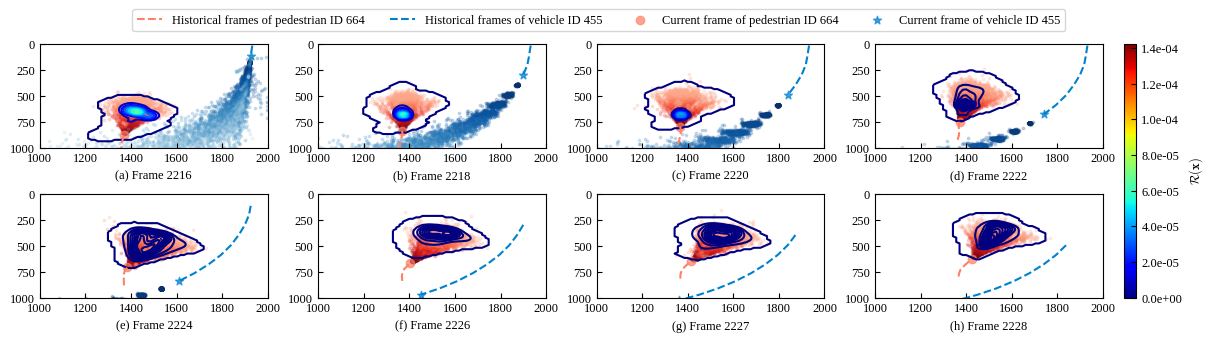

In [27]:
picture_with_field(tra_data,gaussian_parameter,1000,2000,1000,0,
    agent_A='PEDESTRIAN/664',
    agent_B='VEHICLE/455',
    time_duration=list(range(2216, 2216 + 12, 2)) + [2227]+[2228],   # 8 个时间步
    label_A='Historical frames of pedestrian ID 664',
    label_B='Historical frames of vehicle ID 455',
    label_A_1='Current frame of pedestrian ID 664',
    label_B_1='Current frame of vehicle ID 455',save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/sca33.png')

In [28]:
def picture_all_traj_with_bg(
    tra_data,
    x1, x2, y1, y2,
    agent_A, agent_B, time_duration,
    label_A="A history", label_B="B history",
    bg_img_path='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png',
    bg_alpha=0.6,
    save_name=None):
    # ===== 坐标变换系数（保持你原来的设置）=====
    sx = 3840.0 / (23.99 + 55.51)
    ox = 23.99 * sx
    sy = 2160.0 / (7.643 + 38.69)
    oy = 7.64 * sy
    def to_px_x(arr): return arr * sx + ox
    def to_px_y(arr): return arr * sy + oy

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

    # ===== 背景图（放最底层）=====
    try:
        img = plt.imread(bg_img_path)
        ax.imshow(img, extent=[0, 3840, 2160, 0], zorder=0, alpha=bg_alpha)
    except Exception as e:
        print(f"[warning] 背景图读取失败: {e}")

    time_duration = list(time_duration)
    nT = len(time_duration)

    hA_hist = hB_hist = hA_tru = hB_tru = None

    for i, timestep in enumerate(time_duration):
        alpha = 0.15 + 0.65 * (i / max(1, nT - 1))

        try:
            tru_A, his_A, _ = tra_data(timestep, agent_A)
            tru_B, his_B, _ = tra_data(timestep, agent_B)
        except Exception as e:
            print(f"[warning] 读取时间步 {timestep} 轨迹失败: {e}")
            continue

        # history (dashed)
        if his_A is not None and len(his_A) > 1:
            line, = ax.plot(to_px_x(his_A[:, 0]), to_px_y(his_A[:, 1]),
                            '--', lw=6,  zorder=2, color='#ff8066')
            if hA_hist is None: hA_hist = line

        if his_B is not None and len(his_B) > 1:
            line, = ax.plot(to_px_x(his_B[:, 0]), to_px_y(his_B[:, 1]),
                            '--', lw=6,  zorder=2, color='#0081cf')
            if hB_hist is None: hB_hist = line

        # ground-truth (solid)
        if tru_A is not None and len(tru_A) > 1:
            line, = ax.plot(to_px_x(tru_A[:, 0]), to_px_y(tru_A[:, 1]),
                            '-', lw=6,  zorder=3, color='#ff8066')
            if hA_tru is None: hA_tru = line

        if tru_B is not None and len(tru_B) > 1:
            line, = ax.plot(to_px_x(tru_B[:, 0]), to_px_y(tru_B[:, 1]),
                            '-', lw=6,  zorder=3, color='#0081cf')
            if hB_tru is None: hB_tru = line

    # 视野裁剪（如果你想显示全图，可改成 0~3840 / 0~2160）
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)

    handles, labels = [], []
    if hA_hist is not None: handles.append(hA_hist); labels.append(label_A)
    if hB_hist is not None: handles.append(hB_hist); labels.append(label_B)
    # if hA_tru  is not None: handles.append(hA_tru);  labels.append(label_A_1)
    # if hB_tru  is not None: handles.append(hB_tru);  labels.append(label_B_1)
    if handles:
        ax.legend(handles, labels, loc="best", frameon=True)


    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches='tight', pad_inches=0.05)
    else:
        plt.show()

全局颜色范围(原始数据) vmin, vmax = 0.0 0.001869775245678175


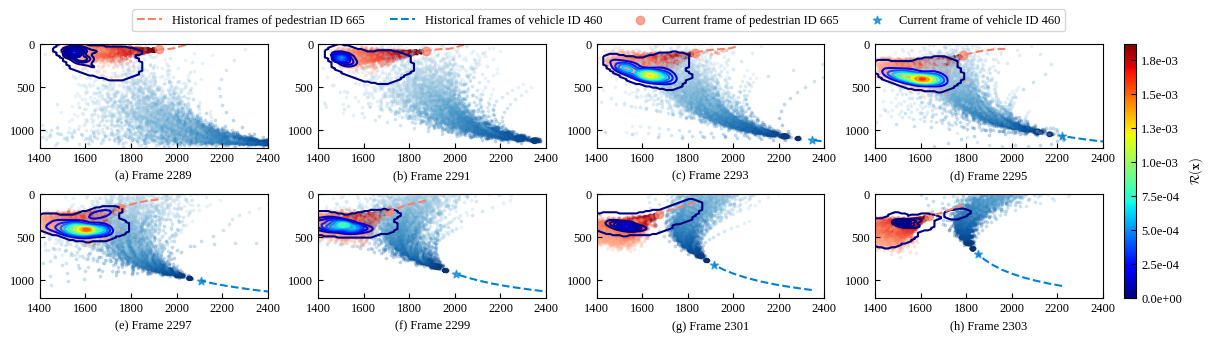

In [29]:
picture_with_field(tra_data,gaussian_parameter,1400,2400,1200,0,
    agent_A='PEDESTRIAN/665',
    agent_B='VEHICLE/460',
    time_duration=range(2289,2289+16,2),   # 8 个时间步
    label_A='Historical frames of pedestrian ID 665',
    label_B='Historical frames of vehicle ID 460',
    label_A_1='Current frame of pedestrian ID 665',
    label_B_1='Current frame of vehicle ID 460',save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/sca22.png')

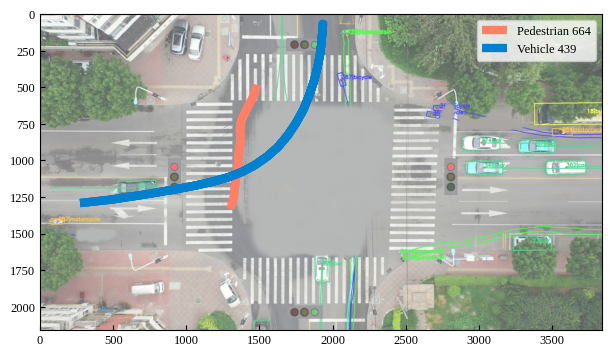

In [30]:
picture_all_traj_with_bg(tra_data,0,3840,2160,0,
    agent_A='PEDESTRIAN/664',
    agent_B='VEHICLE/439',
    time_duration=range(2204,2204+16,2),   # 8 个时间步
    label_A='Pedestrian 664',
    label_B='Vehicle 439',
    bg_img_path='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png',
    bg_alpha=0.7,
    save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/rm1.png')

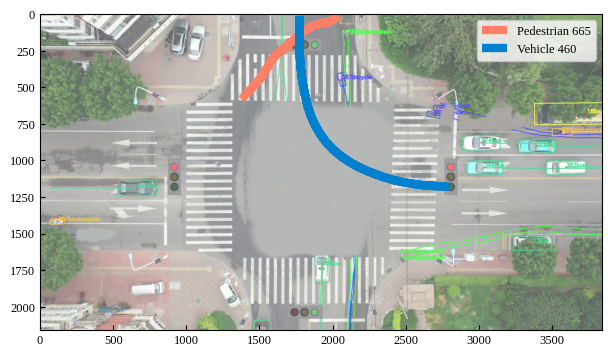

In [31]:
picture_all_traj_with_bg(tra_data,0,3840,2160,0,
    agent_A='PEDESTRIAN/665',
    agent_B='VEHICLE/460',
    time_duration=range(2289,2289+16,2),   # 8 个时间步
    label_A='Pedestrian 665',
    label_B='Vehicle 460',
    bg_img_path='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png',
    bg_alpha=0.7,
    save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/rm2.png')

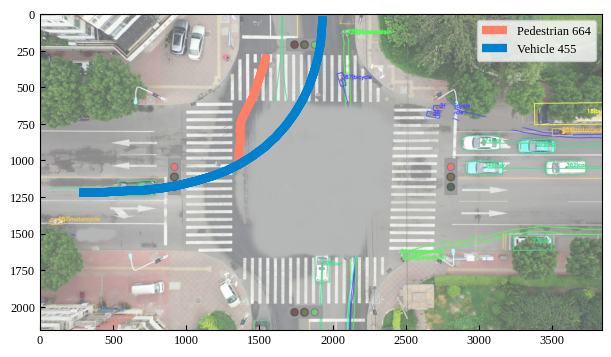

In [32]:
picture_all_traj_with_bg(tra_data,0,3840,2160,0,
    agent_A='PEDESTRIAN/664',
    agent_B='VEHICLE/455',
    time_duration=list(range(2216, 2216 + 12, 2)) + [2227]+[2228],   # 8 个时间步
    label_A='Pedestrian 664',
    label_B='Vehicle 455',
    bg_img_path='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/SinD/SinD_data_tianjing/TJ.png',
    bg_alpha=0.7,
    save_name='/home/wangtao/下载/Trajectron-ped-veh/Data_ana/rm3.png')